In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def noise_kernel_time(ti, tj, tau_c):
    return np.exp(-((ti - tj) ** 2) / (2 * tau_c ** 2))


def dyn_step_single(s0_vec, h0_vec, delta_t):
    """
    Result of evolution in a static magnetic field h0_vec
    for time delta_t starting from s0_vec.
    """
    h0 = np.linalg.norm(h0_vec)
    if h0 != 0:
        chi = np.dot(s0_vec, h0_vec) / h0
        s_vec = (np.cos(h0 * delta_t) * s0_vec +
                 chi * (1 - np.cos(h0 * delta_t)) * h0_vec / h0 +
                 np.sin(h0 * delta_t) * np.cross(h0_vec / h0, s0_vec))
    else:
        s_vec = s0_vec
    return s_vec

def single_traj(time_grid, delta_t, C, amp, delta):
    G_t = np.random.multivariate_normal(np.zeros(len(time_grid)), C)
    hx_t = np.real(G_t * (amp + np.conjugate(amp)))
    hy_t = np.real(G_t * 1j * (amp - np.conjugate(amp)))
    hz_t = delta * np.ones_like(G_t)

    sx_t = np.zeros(len(time_grid))
    sy_t = np.zeros(len(time_grid))
    sz_t = np.zeros(len(time_grid))
    sz_t[0] = 1

    for idx in range(len(time_grid) - 1):
        h0_vec = np.array([hx_t[idx], hy_t[idx], hz_t[idx]])
        s0_vec = np.array([sx_t[idx], sy_t[idx], sz_t[idx]])
        s_vec = dyn_step_single(s0_vec, h0_vec, delta_t)

        [sx_t[idx + 1], sy_t[idx + 1], sz_t[idx + 1]] = s_vec

    return sx_t, sy_t, sz_t


Tmax = 2
delta_t = 0.01
tau_c = 0.1 #noise correlation time
time_grid = np.arange(0, Tmax + delta_t, delta_t)


#cumulative amplitude
amp = 1 * np.exp(1j * 0.34)#amp_1 = A_1 * gamma * np.sin(theta_1) * 1j * np.exp(-1j * phi_1) / 4
delta = 0.#detuning

# The covariance matrix
C = np.array([[noise_kernel_time(ti, tj, tau_c) for tj in time_grid] for ti in time_grid])

In [162]:
# T1 process

Num_traj = 1000

sx_avg = np.zeros(len(time_grid))
sy_avg = np.zeros(len(time_grid))
sz_avg = np.zeros(len(time_grid))

for ind in range(Num_traj):
    sx_t, sy_t, sz_t = single_traj(time_grid, delta_t, C, amp, delta)
    sx_avg += sx_t
    sy_avg += sy_t
    sz_avg += sz_t
sx_avg = sx_avg / Num_traj
sy_avg = sy_avg / Num_traj
sz_avg = sz_avg / Num_traj

    

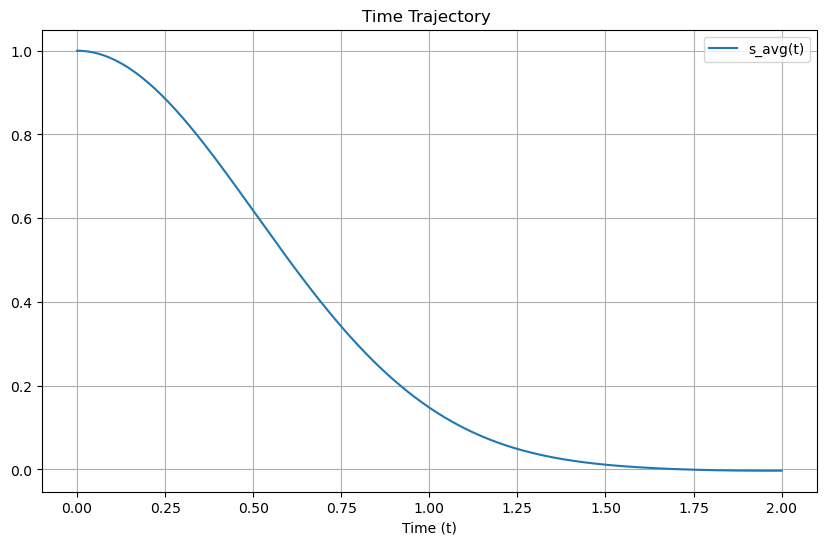

In [163]:
plt.figure(figsize=(10, 6))
plt.plot(time_grid, sz_avg, label='s_avg(t)')
plt.title('Time Trajectory ')
plt.xlabel('Time (t)')
plt.grid(True)
plt.legend()
plt.show()